Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Валидационная выборка: 46 изображений
SAM2 загружен
YOLO OBB загружена


Обработка: 100%|██████████| 46/46 [02:45<00:00,  3.61s/it]



=== МЕТРИКИ ===
Исходный OBB: %TP = 93.5%, mean IoU = 0.923
После SAM2:   %TP = 82.6%, mean IoU = 0.955, gain = +0.032

Выпрямленные изображения сохранены в sam2_rectified


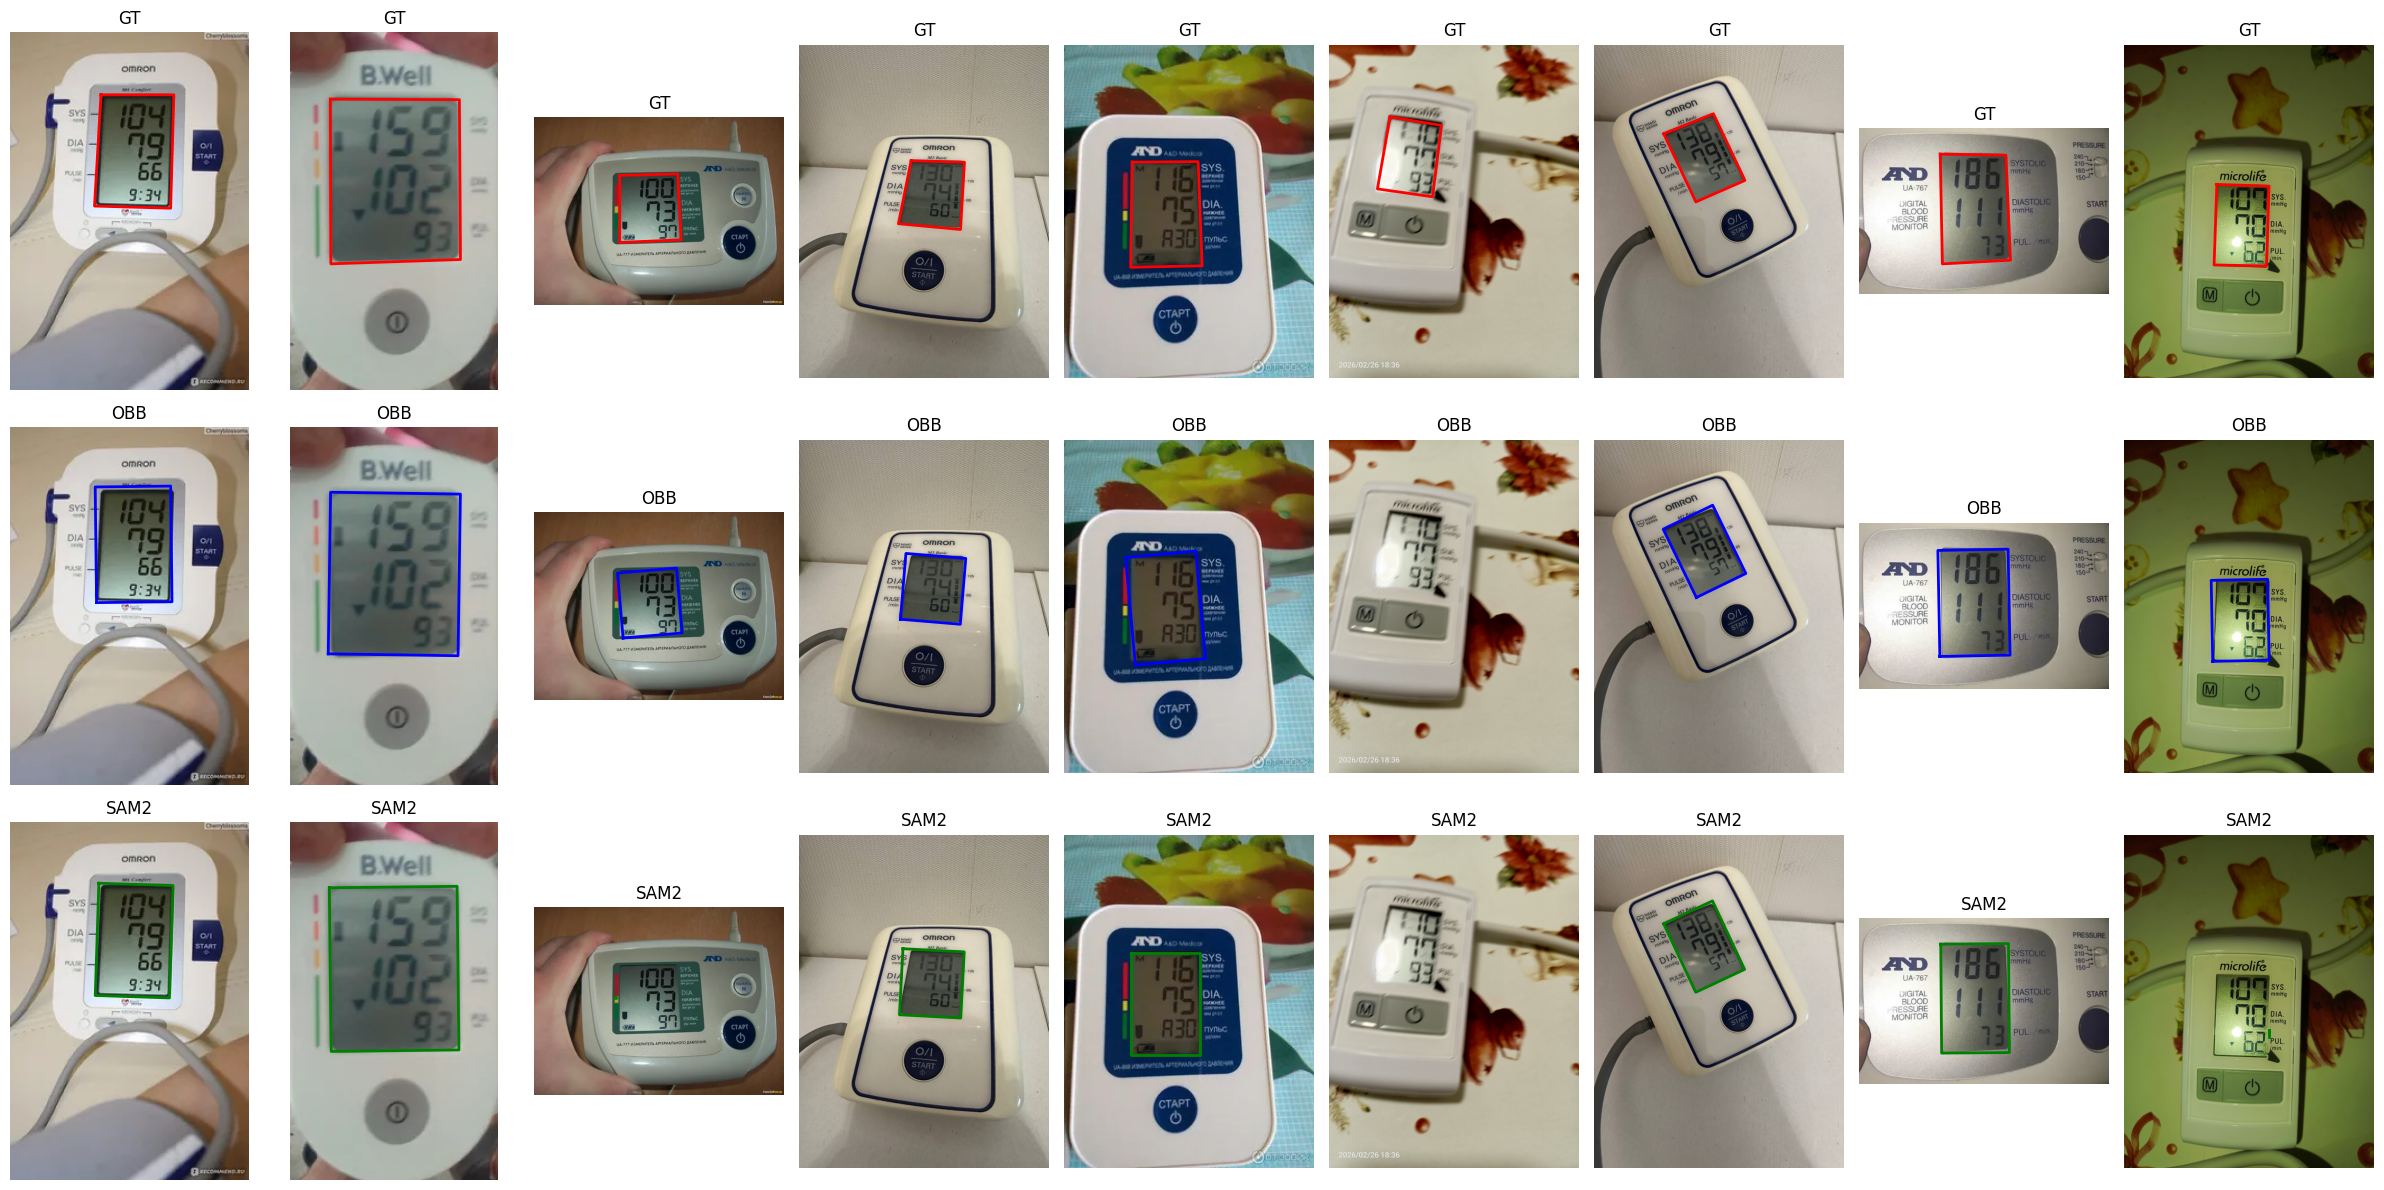

In [1]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from ultralytics import YOLO

# -------- SAM2 ----------
import sys
SAM2_ROOT = Path("./segment-anything-2")
sys.path.insert(0, str(SAM2_ROOT))
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ========== КОНФИГУРАЦИЯ ==========
DATA_DIR = Path("./data")
LABELS_DIR = Path("./labels")
OBB_MODEL_PATH = Path("./runs/obb/yolo_obb_runs/obb_with_aug/weights/best.pt")

# Hydra resolves this path relative to the installed sam2 package.
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_s.yaml"
SAM2_CHECKPOINT = SAM2_ROOT / "checkpoints" / "sam2.1_hiera_small.pt"

VAL_RATIO = 0.2
RANDOM_SEED = 42
IOU_THRESH = 0.8
TARGET_WIDTH = 600            # ширина выпрямленного изображения (пропорции сохраняются)
OUTPUT_DIR = Path("./sam2_rectified")
OUTPUT_DIR.mkdir(exist_ok=True)
MIN_AREA_RATIO = 0.6           # минимальное отношение площади SAM2 к площади OBB
# =================================

def polygon_area(poly):
    """Вычисляет площадь многоугольника по формуле шнурка (Shoelace). poly: list или np.array (Nx2)"""
    poly = np.array(poly)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def load_gt_polygons(json_path):
    """Загружает полигоны (4 точки) из JSON-разметки."""
    if not json_path.exists():
        return []
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    shapes = data.get('shapes', [])
    gt = []
    for shape in shapes:
        points = shape.get('points', [])
        if len(points) >= 4:
            gt.append(np.array(points[:4], dtype=np.float32))
    return gt

def polygon_iou(poly1, poly2, img_shape):
    """IoU двух полигонов (4 точки) через маски."""
    mask1 = np.zeros(img_shape, dtype=np.uint8)
    mask2 = np.zeros(img_shape, dtype=np.uint8)
    cv2.fillPoly(mask1, [np.int32(poly1)], 1)
    cv2.fillPoly(mask2, [np.int32(poly2)], 1)
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return inter / union if union > 0 else 0.0

def order_points_clockwise(pts):
    """Упорядочивает 4 точки по часовой стрелке (верхняя левая -> ...)."""
    pts = np.array(pts)
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:,1] - center[1], pts[:,0] - center[0])
    ordered = pts[np.argsort(angles)[::-1]]
    ordered = ordered[::-1]
    return ordered

def mask_to_rotated_rect(mask):
    """Из бинарной маски получает повёрнутый прямоугольник (4 точки) через minAreaRect."""
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    rect = cv2.minAreaRect(contours[0])
    box = cv2.boxPoints(rect).reshape(-1, 2)
    return order_points_clockwise(box)

def refine_with_sam2(polygon, img_path, predictor):
    """
    Уточняет один полигон с помощью SAM2.
    polygon: список из 4 точек (x,y).
    Возвращает уточнённый полигон (4 точки) или исходный, если SAM2 не дал маску.
    """
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    predictor.set_image(img_rgb)
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    bbox = [int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))]
    masks, scores, _ = predictor.predict(box=bbox, multimask_output=False)
    if masks is not None and len(masks) > 0:
        refined = mask_to_rotated_rect(masks[0])
        if refined is not None:
            return refined.tolist()
    return polygon

def warp_to_rect(image, quad, target_width=TARGET_WIDTH):
    """
    Выпрямляет четырёхугольник в прямоугольник с сохранением пропорций.
    quad: 4 точки (упорядоченные по часовой стрелке).
    """
    quad = np.array(quad, dtype=np.float32)
    if len(quad) != 4:
        return image.copy()
    # Вычисляем стороны
    w1 = np.linalg.norm(quad[1] - quad[0])
    w2 = np.linalg.norm(quad[2] - quad[3])
    h1 = np.linalg.norm(quad[3] - quad[0])
    h2 = np.linalg.norm(quad[2] - quad[1])
    # Защита от вырожденных прямоугольников
    if w1 < 1e-6 or w2 < 1e-6 or h1 < 1e-6 or h2 < 1e-6:
        return image.copy()
    width = (w1 + w2) / 2.0
    height = (h1 + h2) / 2.0
    target_height = int(target_width * (height / width))
    target_height = max(1, target_height)
    dst = np.float32([[0,0], [target_width-1,0], [target_width-1,target_height-1], [0,target_height-1]])
    src = np.float32([quad[0], quad[1], quad[2], quad[3]])
    M = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(image, M, (target_width, target_height))
    return warped

def prepare_val_samples():
    """Возвращает список (путь_изображения, путь_json) для валидационной выборки (20% от всех)."""
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    samples = []
    for img_path in sorted(DATA_DIR.iterdir(), key=lambda path: path.name.casefold()):
        if img_path.suffix.lower() in image_exts:
            json_path = LABELS_DIR / (img_path.stem + '.json')
            if json_path.exists():
                samples.append((img_path, json_path))
    _, val_samples = train_test_split(samples, test_size=VAL_RATIO, random_state=RANDOM_SEED)
    return val_samples

def evaluate_and_rectify(val_samples, model, predictor):
    """Обрабатывает всю валидацию, считает метрики и сохраняет выпрямленные изображения."""
    total_tp_orig = 0
    total_iou_orig = 0.0
    total_tp_ref = 0
    total_iou_ref = 0.0
    n = len(val_samples)

    for img_path, json_path in tqdm(val_samples, desc="Обработка"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        gt = load_gt_polygons(json_path)
        if not gt:
            continue

        res = model(img_path, verbose=False)[0]
        if res.obb is None or len(res.obb) == 0:
            continue
        # Берём первое предсказание (можно улучшить, взяв лучшее по IoU, но для простоты первое)
        obb_pts = res.obb.xyxyxyxy[0].cpu().numpy().reshape(4,2).tolist()
        area_obb = polygon_area(obb_pts)

        # --- Метрика исходного OBB ---
        best_iou = 0.0
        for g in gt:
            iou = polygon_iou(obb_pts, g, (h,w))
            if iou > best_iou:
                best_iou = iou
        if best_iou > IOU_THRESH:
            total_tp_orig += 1
            total_iou_orig += best_iou

        # --- Уточнение через SAM2 ---
        refined_pts = refine_with_sam2(obb_pts, img_path, predictor)
        # Проверка на уменьшение площади
        if refined_pts is not None:
            area_refined = polygon_area(refined_pts)
            if area_refined < MIN_AREA_RATIO * area_obb:
                # Площадь SAM2 слишком мала - используем исходный OBB для выпрямления
                quad_to_use = obb_pts
                # Для метрики всё равно используем refined_pts (чтобы честно оценить SAM2)
            else:
                quad_to_use = refined_pts
        else:
            quad_to_use = obb_pts

        best_iou_ref = 0.0
        for g in gt:
            iou = polygon_iou(refined_pts, g, (h,w))
            if iou > best_iou_ref:
                best_iou_ref = iou
        if best_iou_ref > IOU_THRESH:
            total_tp_ref += 1
            total_iou_ref += best_iou_ref

        # --- Выпрямление и сохранение (с учётом проверки площади) ---
        quad_ordered = order_points_clockwise(quad_to_use)
        warped = warp_to_rect(img, quad_ordered)
        out_path = OUTPUT_DIR / f"{img_path.stem}_rectified.png"
        cv2.imwrite(str(out_path), warped)

    pct_orig = (total_tp_orig / n) * 100
    mean_iou_orig = total_iou_orig / total_tp_orig if total_tp_orig else 0.0
    pct_ref = (total_tp_ref / n) * 100
    mean_iou_ref = total_iou_ref / total_tp_ref if total_tp_ref else 0.0
    return pct_orig, mean_iou_orig, pct_ref, mean_iou_ref

def visualize_9_examples(val_samples, model, predictor):
    """Показывает 9 случайных изображений с наложенными контурами: GT (красный), OBB (синий), SAM2 (зелёный)."""
    selected = random.sample(val_samples, min(9, len(val_samples)))
    fig, axes = plt.subplots(3, 9, figsize=(24, 12))
    for i, (img_path, _) in enumerate(selected):
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gt = load_gt_polygons(LABELS_DIR / (img_path.stem + '.json'))
        res = model(img_path, verbose=False)[0]
        if res.obb is not None and len(res.obb) > 0:
            obb_pts = res.obb.xyxyxyxy[0].cpu().numpy().reshape(4,2)
            refined_pts = refine_with_sam2(obb_pts.tolist(), img_path, predictor)
        else:
            obb_pts = None
            refined_pts = None

        # Ряд 0: GT
        axes[0,i].imshow(img_rgb)
        for g in gt:
            axes[0,i].plot(np.append(g[:,0], g[0,0]), np.append(g[:,1], g[0,1]), 'r-', linewidth=2)
        axes[0,i].axis('off')
        axes[0,i].set_title("GT")

        # Ряд 1: OBB
        axes[1,i].imshow(img_rgb)
        if obb_pts is not None:
            p = obb_pts
            axes[1,i].plot(np.append(p[:,0], p[0,0]), np.append(p[:,1], p[0,1]), 'b-', linewidth=2)
        axes[1,i].axis('off')
        axes[1,i].set_title("OBB")

        # Ряд 2: SAM2 refined
        axes[2,i].imshow(img_rgb)
        if refined_pts is not None:
            r = np.array(refined_pts)
            axes[2,i].plot(np.append(r[:,0], r[0,0]), np.append(r[:,1], r[0,1]), 'g-', linewidth=2)
        axes[2,i].axis('off')
        axes[2,i].set_title("SAM2")
    plt.tight_layout()
    plt.savefig("sam2_refinement_9_examples.png")
    plt.show()

def main():
    val_samples = prepare_val_samples()
    print(f"Валидационная выборка: {len(val_samples)} изображений")

    # Загрузка моделей
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam2 = build_sam2(str(SAM2_CONFIG), str(SAM2_CHECKPOINT), device=device)
    predictor = SAM2ImagePredictor(sam2)
    print("SAM2 загружен")

    model = YOLO(str(OBB_MODEL_PATH))
    print("YOLO OBB загружена")

    # Оценка метрик и сохранение выпрямленных кадров
    pct_orig, iou_orig, pct_ref, iou_ref = evaluate_and_rectify(val_samples, model, predictor)
    print("\n=== МЕТРИКИ ===")
    print(f"Исходный OBB: %TP = {pct_orig:.1f}%, mean IoU = {iou_orig:.3f}")
    print(f"После SAM2:   %TP = {pct_ref:.1f}%, mean IoU = {iou_ref:.3f}, gain = {iou_ref - iou_orig:+.3f}")
    print(f"\nВыпрямленные изображения сохранены в {OUTPUT_DIR}")

    # Визуализация 9 примеров
    visualize_9_examples(val_samples, model, predictor)

if __name__ == "__main__":
    main()

In [2]:
import cv2
import numpy as np
from pathlib import Path

# ========== ПУТИ И ПАРАМЕТРЫ ==========
RECTIFIED_DIR = Path("./sam2_rectified")
OUTPUT_DIR = Path("./best_postprocessed")
OUTPUT_DIR.mkdir(exist_ok=True)

EXCLUDE = ["photo_2026-03-09_15-28-17_rectified.png"]   # исключаемый файл

# Параметры лучшего метода (из вашей таблицы)
EROSION_KERNEL = 3
EROSION_ITER = 1
SMALL_AREA = 500
DILATION_AFTER = True
# =======================================

def thresh_adaptive_mean(gray, block_size=31, C=2):
    return cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, block_size, C)

def remove_small_clusters(binary, min_area=100):
    nb_components, output, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    sizes = stats[1:, -1]
    result = np.zeros_like(binary)
    for i in range(1, nb_components):
        if sizes[i-1] >= min_area:
            result[output == i] = 255
    return result

def apply_best_postprocessing(binary):
    # Эрозия
    if EROSION_KERNEL > 0:
        kernel = np.ones((EROSION_KERNEL, EROSION_KERNEL), np.uint8)
        binary = cv2.erode(binary, kernel, iterations=EROSION_ITER)
    # Удаление маленьких компонент
    if SMALL_AREA > 0:
        binary = remove_small_clusters(binary, min_area=SMALL_AREA)
    # Дилатация (восстановление)
    if DILATION_AFTER and EROSION_KERNEL > 0:
        kernel = np.ones((EROSION_KERNEL, EROSION_KERNEL), np.uint8)
        binary = cv2.dilate(binary, kernel, iterations=EROSION_ITER)
    return binary

def main():
    # Список файлов, исключая указанный
    rectified_files = [f for f in RECTIFIED_DIR.glob("*.png") if f.name not in EXCLUDE]
    print(f"Обрабатывается {len(rectified_files)} изображений (исключён: {EXCLUDE})")

    saved = 0
    for img_path in rectified_files:
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Не удалось загрузить {img_path.name}")
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        binary = thresh_adaptive_mean(gray)
        binary = cv2.bitwise_not(binary)   # инверсия (чтобы объект был белым)
        binary = apply_best_postprocessing(binary)
        out_path = OUTPUT_DIR / img_path.name
        cv2.imwrite(str(out_path), binary)
        saved += 1
        print(f"Сохранено: {out_path}")
    print(f"\nГотово. Сохранено {saved} изображений в папке {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

Обрабатывается 44 изображений (исключён: ['photo_2026-03-09_15-28-17_rectified.png'])
Сохранено: best_postprocessed/photo_2026-02-16_11-45-49_rectified.png
Сохранено: best_postprocessed/IMG_20260301_150507_055_rectified.png
Сохранено: best_postprocessed/image.107_rectified.png
Сохранено: best_postprocessed/photo_10_2026-03-02_09-10-53_rectified.png
Сохранено: best_postprocessed/image.18_rectified.png
Сохранено: best_postprocessed/photo_2026-03-09_15-28-01_rectified.png
Сохранено: best_postprocessed/IMG_20260212_202415_482_rectified.png
Сохранено: best_postprocessed/IMG_20260226_183609_390_rectified.png
Сохранено: best_postprocessed/IMG_20260209_204223_915_rectified.png
Сохранено: best_postprocessed/image.51_rectified.png
Сохранено: best_postprocessed/image.68_rectified.png
Сохранено: best_postprocessed/image.41_rectified.png
Сохранено: best_postprocessed/image.78_rectified.png
Сохранено: best_postprocessed/image.88_rectified.png
Сохранено: best_postprocessed/image.7_rectified.png
Сохра

Найдено пар: 43


Обработка: 100%|██████████| 43/43 [00:00<00:00, 198.08it/s]



=== ЧАСТОТА ОШИБОК (GT → предсказано) ===
  '7' → '0' : 2 раз(а)
  '4' → '5' : 1 раз(а)
  '6' → '8' : 1 раз(а)
  '0' → '8' : 1 раз(а)
  '3' → '1' : 1 раз(а)
  '7' → '1' : 1 раз(а)
  '6' → '1' : 1 раз(а)
  '7' → '8' : 1 раз(а)


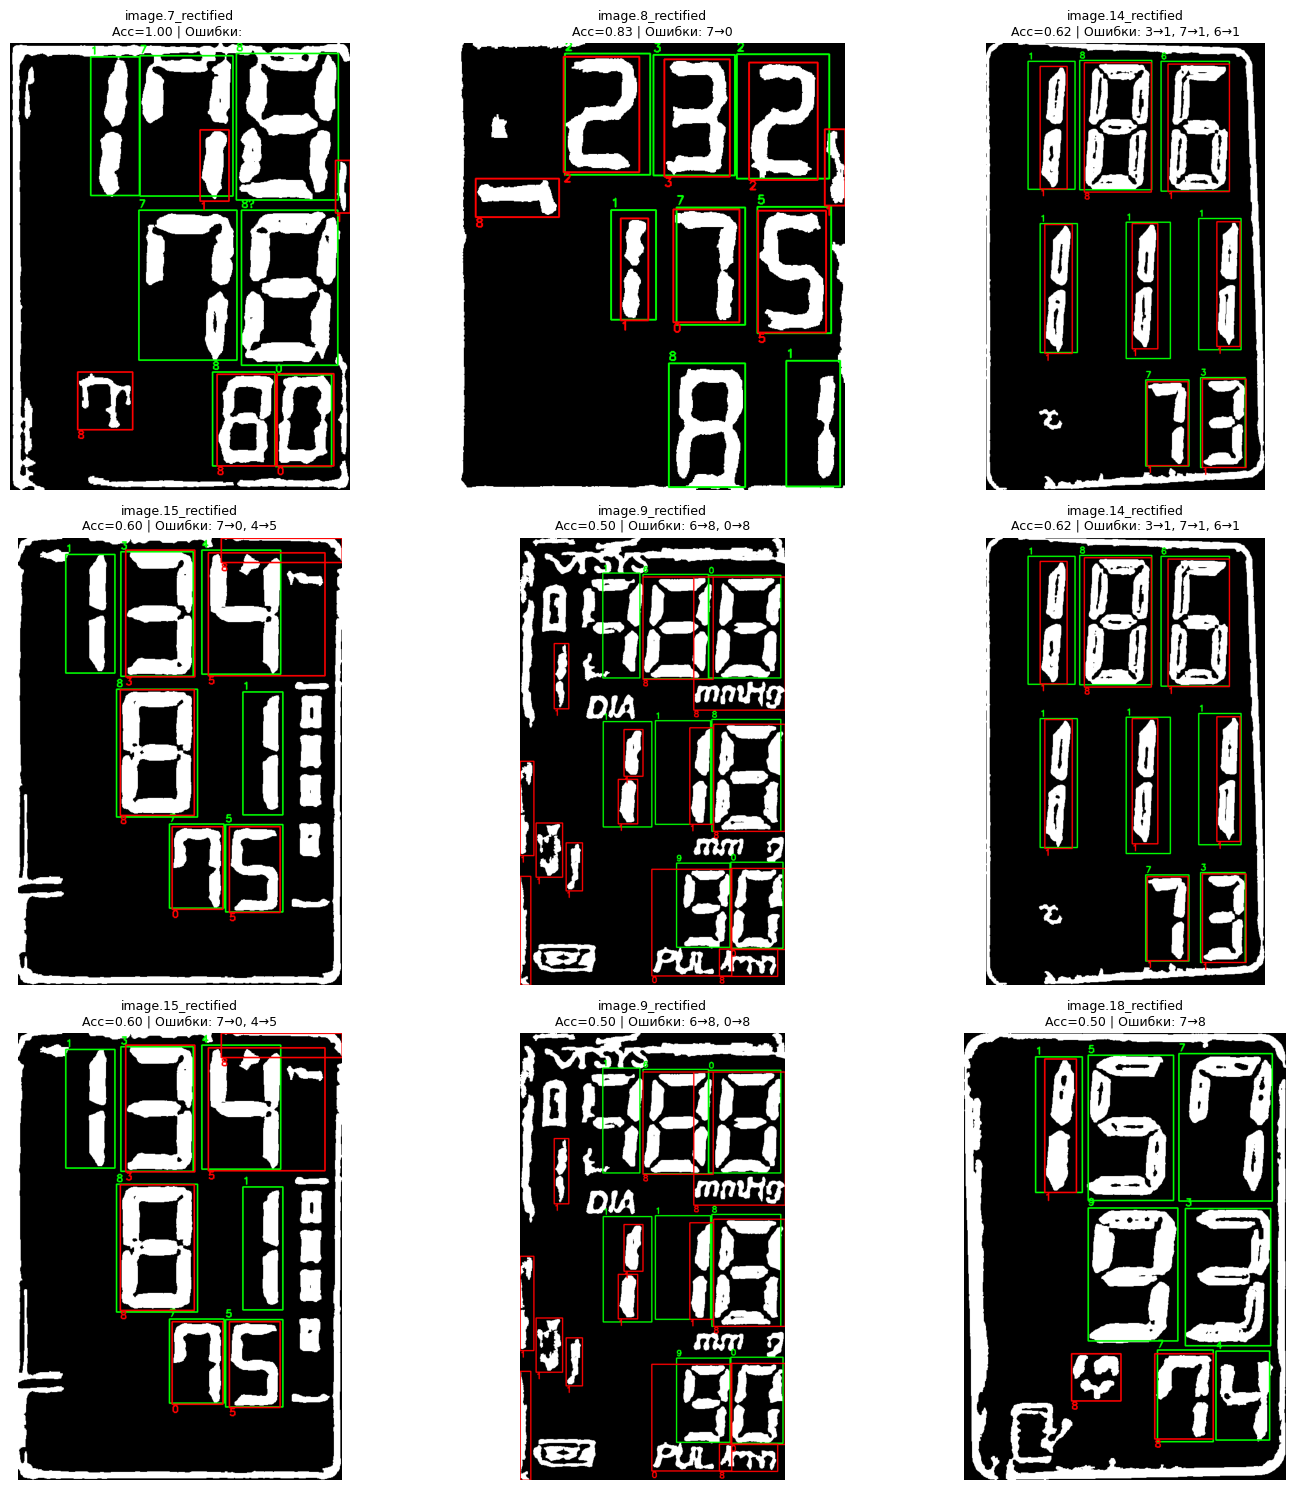

In [3]:
import json
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict

# ========== НАСТРОЙКИ ==========
BINARY_DIR = Path("./best_postprocessed")
ETALON_DIR = Path("./detection_etalon")
IOU_THRESH = 0.5

# Параметры лучшей комбинации (из предыдущих экспериментов)
BEST_MORPH = ('dilate_rect_7_iter2_post_erode', 'dilate', cv2.MORPH_RECT, 7, 2, 0, 1)

MIN_HEIGHT_RATIO = 0.05
MAX_HEIGHT_RATIO = 0.30
MIN_AREA_RATIO = 0.005
MAX_AREA_RATIO = 0.50

# ========== ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ==========
def load_gt_boxes_and_digits(json_path):
    if not json_path.exists():
        return [], []
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    boxes, digits = [], []
    for shape in data.get('shapes', []):
        if shape.get('shape_type') == 'rectangle':
            pts = shape.get('points', [])
            if len(pts) >= 2:
                x1, y1 = pts[0]
                x2, y2 = pts[1]
                x1, x2 = int(min(x1, x2)), int(max(x1, x2))
                y1, y2 = int(min(y1, y2)), int(max(y1, y2))
                boxes.append((x1, y1, x2, y2))
                digits.append(shape.get('description', '?'))
    return boxes, digits

def iou(box1, box2):
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def get_kernel(shape, size):
    return cv2.getStructuringElement(shape, (size, size))

def apply_morphology(img, op, shape, size, it, pre_erode, post_erode):
    kernel = get_kernel(shape, size)
    result = img.copy()
    if pre_erode:
        result = cv2.erode(result, kernel, iterations=1)
    if op == 'dilate':
        result = cv2.dilate(result, kernel, iterations=it)
    elif op == 'close':
        result = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel, iterations=it)
    if post_erode:
        result = cv2.erode(result, kernel, iterations=1)
    return result

def detect_boxes(img, min_size=5):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w >= min_size and h >= min_size:
            boxes.append((x, y, x+w, y+h))
    return boxes

def fill_ratio_filter(box, h, w, img_binary):
    x1,y1,x2,y2 = box
    box_h = y2 - y1
    box_w = x2 - x1
    area = box_w * box_h
    img_area = h * w
    height_ratio = box_h / h
    area_ratio = area / img_area
    if not (MIN_HEIGHT_RATIO <= height_ratio <= MAX_HEIGHT_RATIO and
            MIN_AREA_RATIO <= area_ratio <= MAX_AREA_RATIO):
        return False
    roi = img_binary[y1:y2, x1:x2]
    if roi.size == 0:
        return False
    white_pixels = np.sum(roi > 0)
    fill = white_pixels / roi.size
    return 0.1 <= fill <= 0.8

def group_agglomerative(boxes, h, distance_threshold=0.1):
    if len(boxes) < 2:
        return [boxes] if boxes else []
    centers_y = np.array([(y1+y2)//2 for (x1,y1,x2,y2) in boxes]).reshape(-1,1) / h
    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=distance_threshold)
    labels = clustering.fit_predict(centers_y)
    groups = [[] for _ in range(max(labels)+1)]
    for box, lbl in zip(boxes, labels):
        groups[lbl].append(box)
    groups.sort(key=lambda g: np.mean([(y1+y2)//2 for (x1,y1,x2,y2) in g]))
    for g in groups:
        g.sort(key=lambda b: (b[0]+b[2])//2)
    return groups

def filter_row_overlaps(groups, img_width):
    filtered_groups = []
    for group in groups:
        if len(group) <= 1:
            filtered_groups.append(group)
            continue
        group_sorted = sorted(group, key=lambda b: b[0])
        to_remove = set()
        for i in range(len(group_sorted)-1):
            b1, b2 = group_sorted[i], group_sorted[i+1]
            h1, h2 = b1[3]-b1[1], b2[3]-b2[1]
            if abs(h1 - h2) / max(h1, h2) < 0.2:
                overlap = max(0, min(b1[2], b2[2]) - max(b1[0], b2[0]))
                w1, w2 = b1[2]-b1[0], b2[2]-b2[0]
                if overlap > 0.3 * min(w1, w2):
                    to_remove.add(i)
                    to_remove.add(i+1)
        new_group = [b for idx, b in enumerate(group_sorted) if idx not in to_remove]
        if new_group:
            filtered_groups.append(new_group)
    return filtered_groups

def recognize_7seg_digit(roi):
    if roi is None or roi.size == 0:
        return '?'
    h, w = roi.shape
    border_mean = (np.mean(roi[0,:]) + np.mean(roi[-1,:]) + np.mean(roi[:,0]) + np.mean(roi[:,-1])) / 4.0
    if border_mean > 127:
        roi = 255 - roi
    roi = cv2.medianBlur(roi, 3)
    if w / h < 0.5:
        return '1'
    seg_coords = {
        'A': (0.2, 0.0, 0.8, 0.3), 'B': (0.7, 0.2, 1.0, 0.5),
        'C': (0.7, 0.5, 1.0, 0.8), 'D': (0.2, 0.7, 0.8, 1.0),
        'E': (0.0, 0.5, 0.3, 0.8), 'F': (0.0, 0.2, 0.3, 0.5),
        'G': (0.2, 0.4, 0.8, 0.6)
    }
    active = {}
    for seg, (x1r, y1r, x2r, y2r) in seg_coords.items():
        x1 = int(x1r * w); y1 = int(y1r * h)
        x2 = int(x2r * w); y2 = int(y2r * h)
        x1 = max(0, x1); y1 = max(0, y1); x2 = min(w, x2); y2 = min(h, y2)
        if x1 >= x2 or y1 >= y2:
            active[seg] = False
            continue
        seg_roi = roi[y1:y2, x1:x2]
        active[seg] = np.sum(seg_roi > 128) / seg_roi.size > 0.3
    if active.get('B') and active.get('C') and not active.get('A') and not active.get('D') and not active.get('E') and not active.get('F') and not active.get('G'):
        return '1'
    digits_map = {
        '0': ('A','B','C','D','E','F'), '1': ('B','C'), '2': ('A','B','D','E','G'),
        '3': ('A','B','C','D','G'), '4': ('B','C','F','G'), '5': ('A','C','D','F','G'),
        '6': ('A','C','D','E','F','G'), '7': ('A','B','C'), '8': ('A','B','C','D','E','F','G'),
        '9': ('A','B','C','D','F','G')
    }
    best_digit, best_score = '?', -1
    for digit, required in digits_map.items():
        match = sum(1 for s in required if active.get(s, False))
        extra = sum(1 for s in active if active[s] and s not in required)
        score = match - extra * 0.5
        if score > best_score:
            best_score, best_digit = score, digit
    return best_digit

def match_boxes_with_digits_and_collect(pred_boxes, pred_digits, gt_boxes, gt_digits, iou_thresh=0.5):
    """Возвращает tp, fp, fn, а также список пар (gt_digit, pred_digit) для правильно сопоставленных боксов."""
    if not gt_boxes:
        return [], [], [], []
    used_gt = [False] * len(gt_boxes)
    pairs = []
    for i, p in enumerate(pred_boxes):
        for j, g in enumerate(gt_boxes):
            iou_val = iou(p, g)
            if iou_val > iou_thresh:
                pairs.append((iou_val, i, j))
    pairs.sort(reverse=True, key=lambda x: x[0])
    matched_pred = [False] * len(pred_boxes)
    tp = []
    fp = []
    recog_pairs = []  # (gt_digit, pred_digit)
    for _, i, j in pairs:
        if not matched_pred[i] and not used_gt[j]:
            matched_pred[i] = True
            used_gt[j] = True
            tp.append((pred_boxes[i], gt_boxes[j]))
            recog_pairs.append((gt_digits[j], pred_digits[i]))
    for i, p in enumerate(pred_boxes):
        if not matched_pred[i]:
            fp.append(p)
    return tp, fp, recog_pairs

# ========== ОСНОВНАЯ ФУНКЦИЯ ==========
def main():
    # Загрузка пар
    png_files = list(BINARY_DIR.glob("*.png"))
    json_files = list(ETALON_DIR.glob("*.json"))
    png_dict = {p.stem.replace("_rectified", ""): p for p in png_files}
    pairs = []
    for json_path in json_files:
        name = json_path.stem
        if name.endswith("-1"):
            name = name[:-2]
        key = name.replace("_rectified", "")
        if key in png_dict:
            pairs.append((png_dict[key], json_path))
    print(f"Найдено пар: {len(pairs)}")

    morph_name, op, shape, size, it, pre_erode, post_erode = BEST_MORPH
    # Хранилище результатов по каждому изображению
    image_records = []  # (img_path, accuracy, list_of_error_pairs, img, proc, filtered_boxes, pred_digits, gt_boxes, gt_digits)
    error_counter = defaultdict(int)  # (gt,pred) -> count

    for img_path, json_path in tqdm(pairs, desc="Обработка"):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        if len(img.shape) == 3:
            img = img[:,:,0]
        h, w = img.shape
        gt_boxes, gt_digits = load_gt_boxes_and_digits(json_path)
        if not gt_boxes:
            continue  # без GT не оцениваем
        proc = apply_morphology(img, op, shape, size, it, pre_erode, post_erode)
        pred_raw = detect_boxes(proc)
        pred_boxes = [b for b in pred_raw if fill_ratio_filter(b, h, w, proc)]
        groups = group_agglomerative(pred_boxes, h)
        groups = filter_row_overlaps(groups, w)
        filtered_boxes = [b for group in groups for b in group]
        pred_digits = [recognize_7seg_digit(proc[b[1]:b[3], b[0]:b[2]]) for b in filtered_boxes]
        # Сопоставление и сбор ошибок
        tp, fp, recog_pairs = match_boxes_with_digits_and_collect(filtered_boxes, pred_digits, gt_boxes, gt_digits, IOU_THRESH)
        total_matched = len(recog_pairs)
        correct = sum(1 for g, p in recog_pairs if g == p)
        acc = correct / total_matched if total_matched > 0 else 0.0
        # Запоминаем ошибки для статистики
        for gt_d, pred_d in recog_pairs:
            if gt_d != pred_d:
                error_counter[(gt_d, pred_d)] += 1
        # Сохраняем данные для визуализации
        image_records.append((img_path.stem, acc, recog_pairs, img, proc, filtered_boxes, pred_digits, gt_boxes, gt_digits))
    # --- Вывод статистики ошибок ---
    print("\n=== ЧАСТОТА ОШИБОК (GT → предсказано) ===")
    sorted_errors = sorted(error_counter.items(), key=lambda x: x[1], reverse=True)
    for (gt, pred), count in sorted_errors[:15]:
        print(f"  '{gt}' → '{pred}' : {count} раз(а)")
    # --- Выбор лучших и худших изображений ---
    # Отфильтруем записи, где были сопоставленные боксы (total_matched > 0)
    valid = [r for r in image_records if len(r[2]) > 0]  # r[2] = recog_pairs
    if len(valid) == 0:
        print("Нет изображений с сопоставленными боксами")
        return
    valid_sorted = sorted(valid, key=lambda x: x[1], reverse=True)  # по accuracy
    best5 = valid_sorted[:5]
    worst4 = valid_sorted[-4:]
    # --- Визуализация 3x3 ---
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    # Для лучших и худших создаём список из 9 элементов (5 лучших + 4 худших)
    display_items = best5 + worst4
    for idx, (name, acc, recog_pairs, img, proc, boxes, pred_digits, gt_boxes, gt_digits) in enumerate(display_items):
        if idx >= 9:
            break
        # Создаём цветное изображение для отображения
        vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        # Рисуем GT (зелёным)
        for (x1,y1,x2,y2), d in zip(gt_boxes, gt_digits):
            cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(vis, d, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        # Рисуем предсказанные боксы (синим) с их цифрами
        for (x1,y1,x2,y2), d in zip(boxes, pred_digits):
            cv2.rectangle(vis, (x1,y1), (x2,y2), (255,0,0), 2)
            cv2.putText(vis, d, (x1, y2+15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        axes[idx].imshow(vis)
        # Подпись: имя файла и точность, а также примеры ошибок
        errors = [f"{g}→{p}" for g,p in recog_pairs if g!=p]
        err_str = ", ".join(errors[:3]) + ("..." if len(errors)>3 else "")
        axes[idx].set_title(f"{name}\nAcc={acc:.2f} | Ошибки: {err_str}", fontsize=9)
        axes[idx].axis('off')
    # Убираем пустые подграфики (если меньше 9)
    for idx in range(len(display_items), 9):
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()